# Customer Churn Classification — Fully Connected Network

A Dense network that predicts `Exited` (whether a retail-bank customer left) from the
`Churn_Modelling` customer base.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

print('TensorFlow: ', tf.__version__)
print('Keras', keras.__version__)

TensorFlow:  2.21.0
Keras 3.15.1


In [2]:
churn_data = pd.read_csv('../Churn_Modelling.csv')

print('shape: ', churn_data.shape)
churn_data.head()

shape:  (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
churn_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
churn_data.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
churn_data['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

## Preparing the customer data

Three columns carry no predictive signal and are dropped: `RowNumber` is a positional index,
`CustomerId` is a surrogate key, and `Surname` is free text with 2 932 distinct values that
would leak identity rather than behaviour.

`Geography` is nominal with three levels, so it is one-hot encoded; `Gender` is binary and
collapses to a single 0/1 column. The continuous features live on wildly different scales —
credit scores in the hundreds against balances in the hundred-thousands — so they are
standardised before training, the same reason the Fashion-MNIST pixels were rescaled to
[0, 1] before gradient descent.

In [6]:
IDENTIFIER_COLUMNS = ['RowNumber', 'CustomerId', 'Surname']

churn_features = churn_data.drop(columns=IDENTIFIER_COLUMNS + ['Exited'])
churn_target = churn_data['Exited']

churn_features['Gender'] = (churn_features['Gender'] == 'Male').astype('int8')
churn_features = pd.get_dummies(churn_features, columns=['Geography'], prefix='Geo', dtype='int8')

churn_features.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geo_France,Geo_Germany,Geo_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [7]:
CONTINUOUS_COLUMNS = ['CreditScore', 'Age', 'Tenure', 'Balance',
                      'NumOfProducts', 'EstimatedSalary']

churn_features[CONTINUOUS_COLUMNS].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    churn_features, churn_target,
    test_size=0.2, stratify=churn_target, random_state=42)

feature_scaler = StandardScaler()
X_train[CONTINUOUS_COLUMNS] = feature_scaler.fit_transform(X_train[CONTINUOUS_COLUMNS])
X_test[CONTINUOUS_COLUMNS] = feature_scaler.transform(X_test[CONTINUOUS_COLUMNS])

X_train, X_test = X_train.to_numpy('float32'), X_test.to_numpy('float32')
y_train, y_test = y_train.to_numpy('float32'), y_test.to_numpy('float32')

print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('X data type: ', X_train.dtype)
print('y_train shape: ', y_train.shape)

X_train shape:  (8000, 12)
X_test shape:  (2000, 12)
X data type:  float32
y_train shape:  (8000,)


## Building the network

Same topology as the Fashion-MNIST classifier — three ReLU hidden layers of 256 / 128 / 64
units followed by dropout — with a single sigmoid unit on the output because the target is
binary rather than one of ten classes.

In [9]:
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

churn_model = Sequential(name='churn_fcc')

churn_model.add(Input(shape=X_train[0].shape, name='input'))

churn_model.add(Dense(256, activation='relu', name='hidden_1'))

churn_model.add(Dense(128, activation='relu', name='hidden_2'))

churn_model.add(Dense(64, activation='relu', name='hidden_3'))

churn_model.add(Dropout(0.5))

churn_model.add(Dense(1, activation='sigmoid', name='output'))

churn_model.summary()

Model: "churn_fcc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,545 (174.00 KB)

 Trainable params: 44,545 (174.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
h1_weights, h1_bias = churn_model.get_layer('hidden_1').get_weights()

print(h1_weights.shape)
print(h1_bias.shape)

(12, 256)
(256,)


In [11]:
churn_model.compile(loss='binary_crossentropy',
                    optimizer='adam',
                    metrics=['accuracy',
                             keras.metrics.Precision(name='precision'),
                             keras.metrics.Recall(name='recall'),
                             keras.metrics.AUC(name='auc')])

## Training

Churners are only 20 % of the base. Without re-weighting the loss the network settles on the
majority class and reports a flattering 80 % accuracy while recalling almost no one who
actually left, so each class contributes inversely to its frequency.

In [12]:
class_weight = {label: len(churn_target) / (2 * count)
                for label, count in churn_target.value_counts().items()}

class_weight

{0: 0.6279040562602034, 1: 2.454590083456063}

In [13]:
checkpoint_cb = ModelCheckpoint('churn_model.keras', save_best_only=True)
early_stopping_cb = EarlyStopping(patience=10, restore_best_weights=True)
lr_cb = ReduceLROnPlateau(patience=5)

churn_history = churn_model.fit(X_train, y_train,
                                epochs=60, batch_size=32,
                                validation_split=0.2,
                                class_weight=class_weight,
                                callbacks=[checkpoint_cb, early_stopping_cb, lr_cb])

Epoch 1/60


  1/200 ━━━━━━━━━━━━━━━━━━━━ 3:47 1s/step - accuracy: 0.4062 - auc: 0.4423 - loss: 0.6899 - precision: 0.1579 - recall: 0.5000

 26/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6286 - auc: 0.6678 - loss: 0.6270 - precision: 0.2680 - recall: 0.6284 

 52/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6556 - auc: 0.7005 - loss: 0.6232 - precision: 0.3144 - recall: 0.6462

 79/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6733 - auc: 0.7206 - loss: 0.6185 - precision: 0.3404 - recall: 0.6608

...

 68/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8208 - auc: 0.9173 - loss: 0.3625 - precision: 0.5360 - recall: 0.8314

101/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8298 - auc: 0.9223 - loss: 0.3532 - precision: 0.5542 - recall: 0.8326

136/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8249 - auc: 0.9170 - loss: 0.3640 - precision: 0.5479 - recall: 0.8283

169/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8236 - auc: 0.9155 - loss: 0.3686 - precision: 0.5488 - recall: 0.8256

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8255 - auc: 0.9189 - loss: 0.3611 - precision: 0.5484 - recall: 0.8351 - val_accuracy: 0.8044 - val_auc: 0.8603 - val_loss: 0.4191 - val_precision: 0.5075 - val_recall: 0.7406 - learning_rate: 1.0000e-04


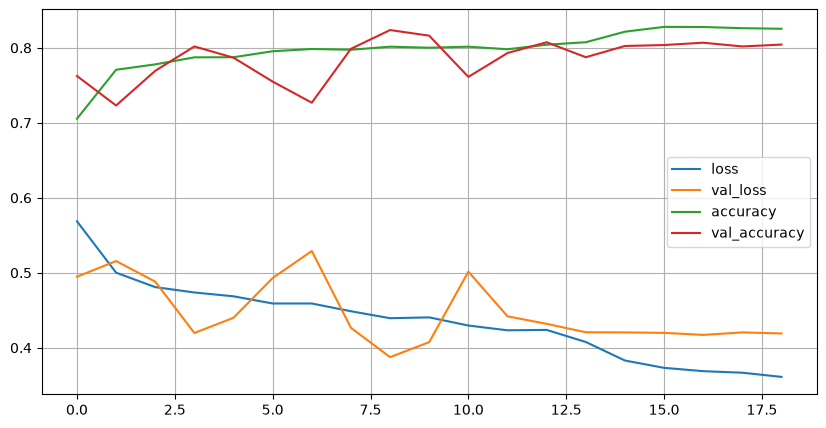

In [14]:
import matplotlib.pyplot as plt

learning_data = pd.DataFrame(churn_history.history)
learning_data[['loss', 'val_loss', 'accuracy', 'val_accuracy']].plot(figsize=(10, 5))
plt.grid(True)
plt.show()

## Evaluating on the held-out customers

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

churn_probabilities = churn_model.predict(X_test, verbose=0).ravel()
churn_predictions = (churn_probabilities >= 0.5).astype('int8')

print(confusion_matrix(y_test, churn_predictions))
print(classification_report(y_test, churn_predictions, target_names=['Retained', 'Exited']))

[[1366  227]
 [ 133  274]]
              precision    recall  f1-score   support

    Retained       0.91      0.86      0.88      1593
      Exited       0.55      0.67      0.60       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.74      2000
weighted avg       0.84      0.82      0.83      2000



In [16]:
X_new = X_test[5].reshape(1, -1)
churn_probability = float(churn_model.predict(X_new, verbose=0)[0, 0])

print('actual value     ', int(y_test[5]))
print('predicted value  ', int(churn_probability >= 0.5))
print('churn probability', round(churn_probability, 4))

actual value      0
predicted value   0
churn probability 0.4746


In [17]:
test_scores = churn_model.evaluate(X_test, y_test, verbose=0, return_dict=True)

print('Churn classifier - test set performance')
print(f"  loss      : {test_scores['loss']:.4f}")
print(f"  accuracy  : {test_scores['accuracy']:.4f}")
print(f"  precision : {test_scores['precision']:.4f}")
print(f"  recall    : {test_scores['recall']:.4f}")
print(f"  roc auc   : {test_scores['auc']:.4f}")

Churn classifier - test set performance
  loss      : 0.4074
  accuracy  : 0.8200
  precision : 0.5469
  recall    : 0.6732
  roc auc   : 0.8504
